In [43]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics


In [8]:
data=load_iris()

In [21]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [22]:
df.shape

(150, 5)

In [27]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [28]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [29]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


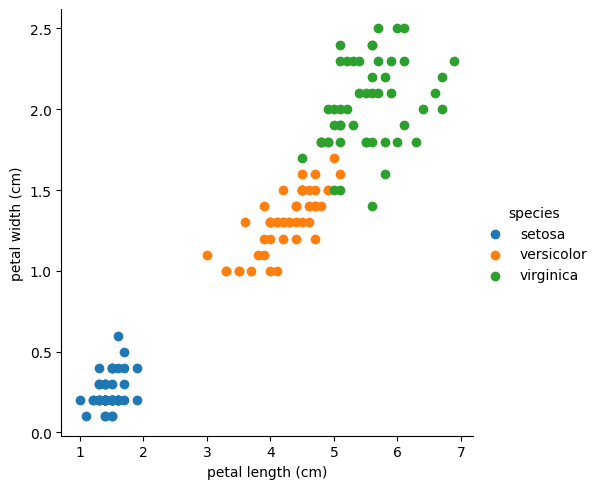

In [34]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'petal length (cm)','petal width (cm)').add_legend()
plt.show()

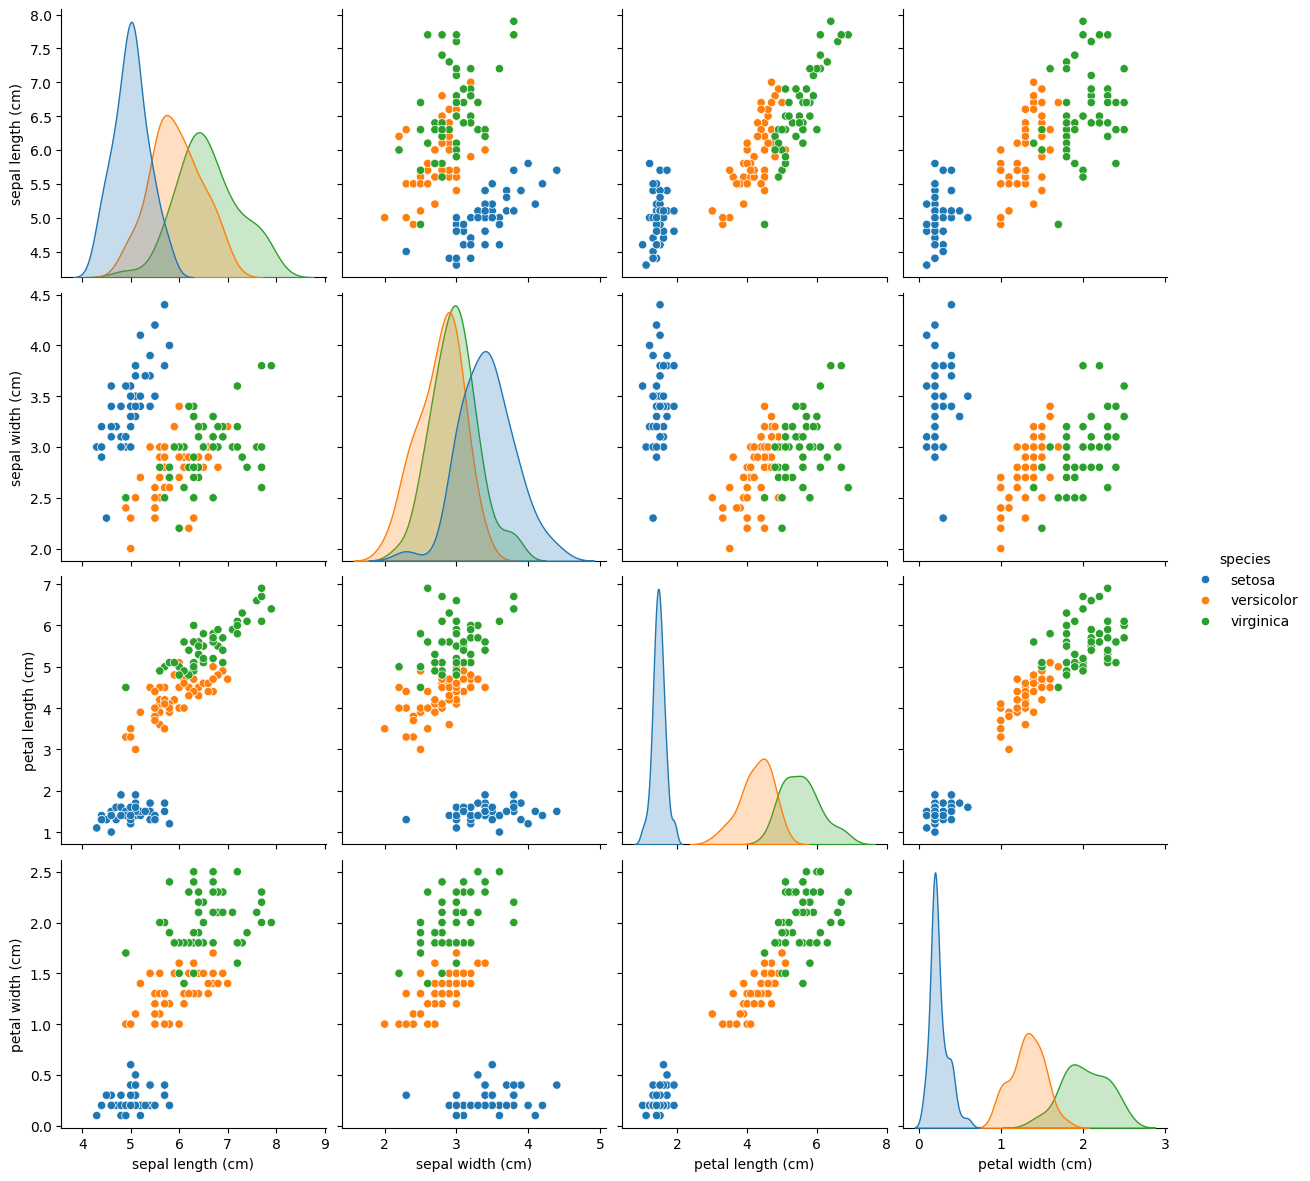

In [35]:
sns.pairplot(df,hue='species',height=3)
plt.show()

In [10]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df['species']=data.target

In [11]:
df['species']=df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})

In [12]:
x=df.drop('species',axis=1)
y=df['species']

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
x_train.shape

(120, 4)

In [14]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [15]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy}")

Accuracy:1.0


In [17]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


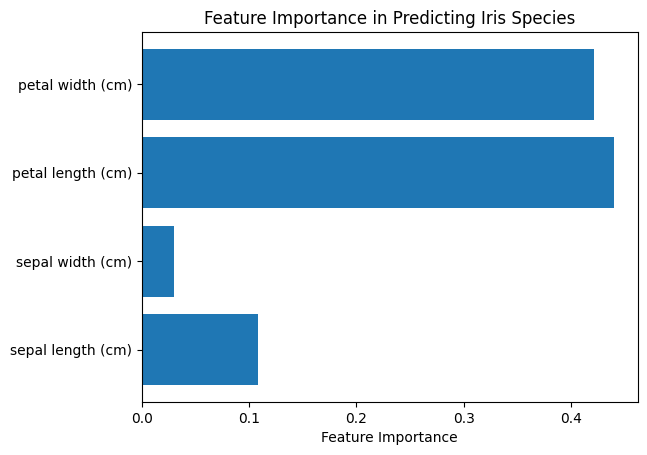

In [19]:
importances=model.feature_importances_
feature_names=x.columns
plt.barh(feature_names,importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Predicting Iris Species')
plt.show()



In [40]:
expected=df.species
predicted=model.predict(x)

In [44]:
print(metrics.classification_report(expected,predicted))
print(metrics.confusion_matrix(expected, predicted))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      1.00      1.00        50
   virginica       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]


In [45]:
predicted=model.predict(x_test)
predicted

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Customized model
model = RandomForestClassifier(
    n_estimators=150,        # Try 100, 150, 200, etc.
    max_depth=4,             # Try 3–10; lower = more regularization
    min_samples_split=5,     # Prevents overfitting on small splits
    random_state=42
)

model.fit(x_train, y_train)


RandomForestClassifier(max_depth=4, min_samples_split=5, n_estimators=150,
                       random_state=42)

In [49]:
y_pred = model.predict(x_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
